**Import the Dependenicies**

In [ ]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
from sksurv.util import Surv

**Load the Data from Excel into Dataframes**

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/train.csv', index_col = "event_id")
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/test.csv', index_col = "event_id")
sample_submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/sample_submission.csv')
metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/metaData.csv')

In [ ]:
metadata.head()

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN


In [ ]:
df_test.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
event_id,,,,,,,,,,,,,,,,,,,,,
10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,0.186363,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


In [ ]:
# Sample submission data
sample_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


**Exploratory Data Analysis (EDA)**

In [ ]:
df_train.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
event_id,,,,,,,,,,,,,,,,,,,,,
10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [ ]:
print("Shape: ", df_train.shape)
print(df_train.info())

Shape:  (221, 36)
<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 10892457 to 99339733
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-n

In [ ]:
# Time that had the most numbers of event starting-time observations
event_start_hour = df_train["event_start_hour"].value_counts()
event_start_hour


,count
event_start_hour,
21,33
22,30
20,23
18,20
23,18
0,16
19,13
16,11
2,9


In [ ]:
# High values for both features signifies an aggressive mobile fire
df_train[["area_growth_rate_ha_per_h", "centroid_speed_m_per_h"]].sort_values(by = "centroid_speed_m_per_h",ascending = False ).head()

,area_growth_rate_ha_per_h,centroid_speed_m_per_h
event_id,,
70401139,182.820074,595.058697
60132804,520.443033,424.426546
59863246,124.525831,258.006167
80550714,88.573191,235.166604
84940844,31.054997,216.184540


In [ ]:
# Fire directly approaching evac zone quickly (When both features are high)
df_train[["closing_speed_m_per_h", "alignment_abs"]].sort_values(by = "closing_speed_m_per_h", ascending = False).head()

,closing_speed_m_per_h,alignment_abs
event_id,,
60132804,354.120897,0.902628
49907151,134.637726,0.994594
65120642,93.922570,0.796469
69453871,25.336113,0.326959
54555851,18.506421,0.231012


In [ ]:
# What percentage of fires hit?
event = (df_train["event"]).value_counts()
event

,count
event,
0,152
1,69


In [ ]:
# Unique area growth rate where fire hit evacuation zones(event = 1) within 72h
df_train["area_growth_rate_ha_per_h"][df_train["event"] == 1].unique()

array([ 0.00000000e+00,  4.16444985e+00,  8.19766902e+00,  1.07844859e+01,
        3.44630084e+00,  5.54749656e-04,  3.18730805e+00,  3.01816268e+00,
        6.50236167e+01,  2.90669901e+01,  5.20443033e+02,  1.32352921e+01,
        1.68409928e+02,  1.82820074e+02,  7.03124540e+00, -5.29284592e-06,
        8.85731908e+01,  3.10549968e+01,  6.62920158e-04])

In [ ]:
df_train["event_start_hour"].describe()

,event_start_hour
count,221.000000
mean,15.429864
std,7.921250
min,0.000000
25%,9.000000
50%,19.000000
75%,21.000000
max,23.000000


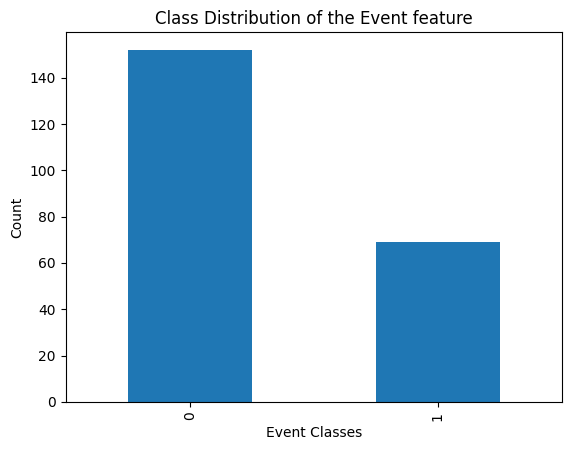

In [ ]:
# Bar chart of the event classes
event.plot(
    kind = "bar",
    )

plt.xlabel("Event Classes")
plt.ylabel("Count")
plt.title("Class Distribution of the Event feature");

<Axes: xlabel='event', ylabel='event_start_hour'>

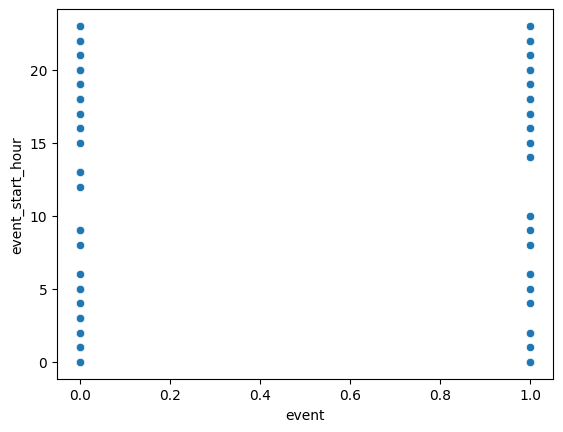

In [ ]:
sns.scatterplot(
    x = df_train["event"],
    y = df_train["event_start_hour"]
)

In [ ]:
df_train["time_to_hit_hours"].unique()

array([1.88925118e+01, 2.20481080e+01, 8.88895483e-01, 6.09530215e+01,
       4.49902745e+01, 4.40263836e+01, 1.48453918e+01, 6.67679270e+01,
       3.99126301e+01, 5.46381094e+01, 6.66439690e+01, 1.59246879e+01,
       1.09074590e+01, 1.82804653e+01, 5.54643427e+01, 6.45674854e+01,
       2.38438434e+01, 3.53484561e+00, 5.81815958e+00, 6.64281031e+01,
       3.73947605e+01, 2.41724995e+01, 6.64422306e+01, 6.12658726e+01,
       5.23763411e-01, 5.76438066e+01, 1.39796932e+00, 2.56443962e+00,
       6.28166641e+01, 4.89252955e+01, 5.84172862e-01, 5.45866301e+00,
       3.76167108e+01, 6.62710855e+01, 6.37164247e+01, 1.88046103e+01,
       3.21134343e+00, 1.47281399e+01, 6.64039128e+01, 6.56896544e+01,
       6.64489979e+01, 1.12543443e+01, 1.47523102e+00, 1.99296374e+00,
       4.44304912e+00, 1.28211783e+01, 5.97708404e+01, 1.57785977e+00,
       6.03139902e+01, 6.14817681e+01, 4.79970215e+01, 6.50849293e+01,
       6.62960358e+01, 1.36567870e+01, 2.10724622e+01, 6.61317720e+01,
      

From above observations, most fires that hit (event = 1), they started at 7pm; median(50%) = 19. <br> Also, event = 1 has some outliers, represented by the circles before the minimum mark.

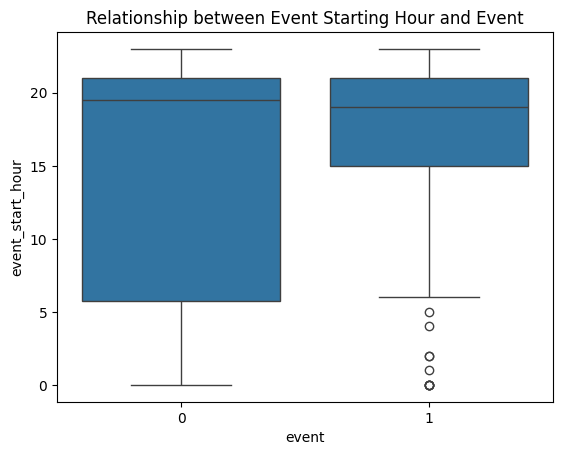

In [ ]:
# At what time time did most fires hit?
sns.boxplot(
    x = df_train["event"],
    y = df_train["event_start_hour"]
)
plt.title("Relationship between Event Starting Hour and Event");

In [ ]:
# Correlation between all features except the target features
corr = df_train.drop(columns = ["time_to_hit_hours", "event"]).corr()
print("Correlation matrix: ")
corr.head()

Correlation matrix: 


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
num_perimeters_0_5h,1.000000,0.667314,-0.673017,-0.117057,0.474259,0.502281,0.522499,-0.109423,0.784831,0.724456,...,0.315076,-0.267586,0.436162,0.077316,0.590605,0.172545,0.074457,0.156423,0.010015,-0.043686
dt_first_last_0_5h,0.667314,1.000000,-0.923622,-0.172628,0.281809,0.195953,0.289782,-0.198299,0.514515,0.345499,...,0.180727,-0.203947,0.497341,0.035579,0.823127,0.062732,0.083141,0.202332,-0.005273,0.014960
low_temporal_resolution_0_5h,-0.673017,-0.923622,1.000000,0.199176,-0.230652,-0.225602,-0.250207,0.281554,-0.476915,-0.357717,...,-0.131277,0.143319,-0.439878,0.022043,-0.861182,-0.070261,-0.019370,-0.184362,-0.007760,-0.026156
area_first_ha,-0.117057,-0.172628,0.199176,1.000000,0.037155,-0.044999,0.029056,0.621912,-0.046068,-0.058269,...,0.043750,-0.033100,-0.058690,0.019055,-0.171052,-0.049385,0.043538,-0.184683,0.064508,-0.019375
area_growth_abs_0_5h,0.474259,0.281809,-0.230652,0.037155,1.000000,0.325878,0.991339,0.103716,0.669160,0.486166,...,0.855030,-0.737906,0.344149,0.177724,0.220966,-0.122571,0.418101,0.067744,-0.041576,-0.078409


In [ ]:
event_class = df_train["event"].value_counts()
event_class

,count
event,
0,152
1,69


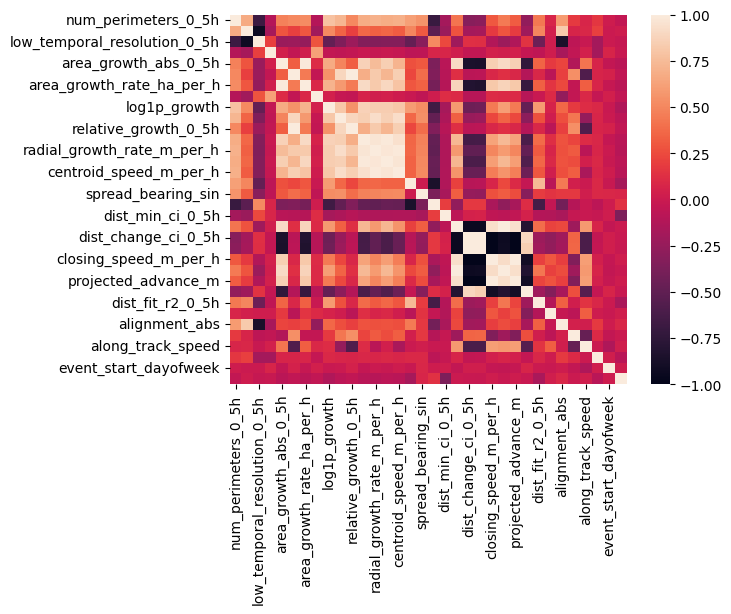

In [ ]:
sns.heatmap(corr);
# The heatmap shows signs of multicollinearity

In [ ]:
# Identify the feature matrix (X) and the target vector (y)
# The test data lacks the target features thus created a horizontal split so as acquire y_test for accuracy scoring purposes
target = ["event", "time_to_hit_hours"]
X_train = df_train.drop(columns = target)[95:]
y_train = df_train[target][95:]
y_test = df_train[target][:95]

In [ ]:
len(y_train)

126

In [ ]:
df_train[target[0]]

,event
event_id,
10892457,0
11757157,1
11945086,1
12044083,0
12052347,0
...,...
97075632,0
97362560,1
97805715,0


In [ ]:
# The ensemble model is sensitive to format of data hence converted to compatible arrays using surv class
y_train = Surv.from_arrays(event=df_train[target[0]][95:], time=df_train[target[1]][95:])
y_test = Surv.from_arrays(event=df_train[target[0]][:95], time=df_train[target[1]][:95])

In [ ]:
# Number of rows & columns in training feature matrix and target vector
print(X_train.shape)
print(y_train.shape)

(126, 34)
(126,)


In [ ]:
# The event field in the ensemble model should be of boolean type (info found in documentation)
df_train["event"] = df_train["event"].astype(bool)

**Build Model Before Random Sampling**

In [ ]:
# Instantiate RandomSurvivalForest
rsf = RandomSurvivalForest(
    n_estimators = 100,
    max_depth = 100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)



In [ ]:
rsf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


,n_estimators,100
,max_depth,100
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [ ]:
rsf.predict(df_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


array([ 1.66721993, 16.70889994,  1.14631682, 18.98556971, 26.05087617,
        1.02106876,  2.04535207, 12.60701139,  0.93305351, 17.96404488,
        1.495094  ,  2.9410557 , 26.71973895,  1.28692183,  0.70750234,
        1.10927948,  2.58981334,  2.97161933, 37.8172408 ,  2.57872969,
       12.70697338,  0.71104393, 13.86066096,  1.73810167,  2.05550829,
       13.42383282,  1.51888727, 32.07433397,  0.76752333, 15.93657451,
       16.13776268,  9.56508435, 16.16615435,  1.38573977,  3.3778789 ,
       35.94166192, 14.19628635,  7.61202769,  1.9068397 ,  1.16886091,
        1.04053669,  1.76793021,  3.18261762,  1.43258088,  1.93705911,
        0.91388082,  1.28306078, 24.20027324, 22.05346254,  5.51968907,
        9.13212814,  1.01383209, 18.01275948, 25.59407206,  1.03883067,
       22.4550338 , 34.2837413 ,  1.49509904,  2.99212652,  1.0779961 ,
        0.6983259 , 19.23249233, 16.6493419 ,  0.7161871 , 18.56051891,
        5.02692559,  0.75165923,  1.33498136,  1.83399825, 16.01

In [ ]:
rsf.score(df_test, y_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(0.5743305632502308)

**Summary** </br>
The above modelling was carried without mitigating overfitting all considering the fact that data is limited. </br>
An ensemble model was used and the accuracy score is 0.574330, which is not great. </br>
Things to look in the next modellling phase is hyperparameter tuning and ways to reduce overfitting and improving the accuracy score


# **Version 2: Modelling phase**

Explore the RandomSurvivalForest by introducing hyperparameter tuning to get the best estimator

In [ ]:
# Hyperparameter tuning
params = {
    "n_estimators": range(10, 200, 10),
    "max_depth": range(10, 100, 10)
}


In [ ]:
model = GridSearchCV(
    estimator=rsf,
    param_grid=params,
    n_jobs=-1,
    cv=5
)

In [ ]:
model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 170 out of 170 | elapsed:    0.2s finished


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","RandomSurviva...42, verbose=1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 100, 10), 'n_estimators': range(10, 200, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

np.float64(0.9171912997889897)

In [ ]:
model.best_score_

np.float64(0.9171912997889897)

In [1]:
model.best_estimator_.score

NameError: name 'model' is not defined

In [ ]:
pd.DataFrame().from_dict(model.cv_results_).head(10)

In [ ]:
model.predict(df_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 170 out of 170 | elapsed:    0.1s finished


array([ 1.89752136, 16.25884335,  1.12546829, 19.32949772, 24.54704909,
        1.12722735,  1.96653117, 11.77770506,  0.84113715, 17.36725901,
        1.43819029,  2.68595417, 29.1698696 ,  1.21351969,  0.67940022,
        0.97772874,  2.22281381,  2.77253216, 39.07528718,  2.4147575 ,
       13.08630788,  0.59230749, 12.6041488 ,  1.65344229,  1.87205554,
       13.35474802,  1.23815582, 29.70640985,  0.74258624, 15.65603122,
       16.26765978,  8.55788441, 15.0363505 ,  1.24933495,  3.23659717,
       37.96553343, 14.09869473,  7.5465365 ,  2.18322825,  1.23438886,
        1.07541308,  1.69769057,  2.87654879,  1.12325165,  1.6116774 ,
        0.82005518,  1.10045515, 25.66696305, 21.99415796,  5.43697198,
        6.47886406,  0.7912171 , 16.81398708, 27.55082889,  1.36268533,
       25.77427597, 35.64062745,  1.566324  ,  2.98299134,  0.96026605,
        0.65718814, 22.18733832, 15.75626695,  0.6297423 , 18.84830688,
        4.31597988,  0.71307049,  1.17529826,  1.45682151, 15.78

In [ ]:
model.socre